### Conditional Workflow with LLMs

Example: Based Review Handling

Based on a customer review, we first generate a sentiment. If it's positive, we return a positive_response. If it's negative, we run a diagnosis where we extract issue_type, tone, and urgency, and based on these we generate a negative_response.

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
load_dotenv()

True

In [5]:
model = ChatOpenAI(model="gpt-4.1-nano")

In [7]:
class Sentiment(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description="The sentiment of the review, either 'positive' or 'negative'.")

In [10]:
sentiment_model = model.with_structured_output(Sentiment)

In [11]:
a = sentiment_model.invoke("The movie was fantastic! I really enjoyed it.")
a.sentiment

'positive'

In [12]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

diagnosis_model = model.with_structured_output(DiagnosisSchema)
b = diagnosis_model.invoke("The app crashes every time I try to upload a photo, and it's really frustrating!")
b.issue_type, b.tone, b.urgency

('Bug', 'frustrated', 'high')

In [14]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [ ]:
def find_sentiment(state: ReviewState):
    prompt = f'Determine the sentiment of the following review: "{state["review"]}"'
    sentiment = sentiment_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def positive_response(state: ReviewState):
    prompt = f'Write a warm thank you message in response to the following review: "{state["review"]}", and ask the user to leave a feedback on our website.'
    response = model.invoke(prompt).content
    return {'response': response}

def run_diagnosis(state: ReviewState):
    prompt = f'Analyze the following review and identify the issue type, emotional tone, and urgency: "{state["review"]}"'
    diagnosis = diagnosis_model.invoke(prompt)
    return {'diagnosis': diagnosis.model_dump()}

def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

def check_sentiment(state:ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    return 'positive_response' if state['sentiment'] == 'positive' else 'run_diagnosis'

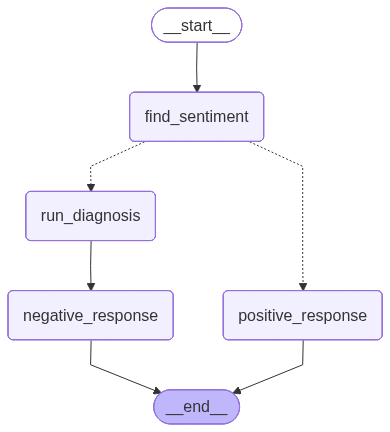

In [15]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)
graph.add_node('positive_response', positive_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)
graph.add_edge('positive_response', END)

workflow = graph.compile()
workflow

In [16]:
initial_state = {
    'review': "The app crashes every time I try to upload a photo, and it's really frustrating!"}

final_state = workflow.invoke(initial_state)
final_state

{'review': "The app crashes every time I try to upload a photo, and it's really frustrating!",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Hello,\n\nI'm really sorry to hear you're experiencing this issue, and I understand how frustrating it can be when things aren't working as expected. I want to assure you that we're prioritizing your case and doing everything we can to resolve this quickly.\n\nTo assist you effectively, could you please provide a few additional details about the bug you're encountering? For example, any error messages, the steps leading up to the issue, and your system setup would be very helpful.\n\nIn the meantime, I recommend trying some basic troubleshooting steps, such as restarting the application or device, and ensuring that all your software is up to date.\n\nThank you for your patience and for bringing this to our attention. We're committed to resolving this as swiftly as possible and

In [18]:
initial_state = {
    'review': "The food was alright, but very cheap so eh."}

final_state = workflow.invoke(initial_state)
final_state

{'review': 'The food was alright, but very cheap so eh.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Other',
  'tone': 'disappointed',
  'urgency': 'low'},
 'response': "I'm sorry to hear you're experiencing difficulties. I understand how frustrating this must be, especially when it feels like your concerns aren't being addressed promptly. I'm here to help and will do my best to assist you in resolving the issue as smoothly as possible. Please provide any additional details or specific challenges you're facing, and I'll work with you to find a solution. Thank you for your patience."}

In [17]:
initial_state = {
    'review': "Ana was super helpful and friendly when I had an issue with my order. She resolved it quickly and made sure I was satisfied with the solution. Great customer service!"}

final_state = workflow.invoke(initial_state)
final_state

{'review': 'Ana was super helpful and friendly when I had an issue with my order. She resolved it quickly and made sure I was satisfied with the solution. Great customer service!',
 'sentiment': 'positive',
 'response': "Thank you so much for your kind words! We're delighted to hear that Ana provided you with helpful and friendly service, and that she was able to resolve your issue quickly. Your satisfaction is our top priority, and we're glad we could meet your expectations. If you have a moment, we'd love for you to share your feedback on our website as well. Thank you again for your support!"}